# 01 — Linear Classifiers: SVM & Softmax

Tests `dl/models/linear_classifier.py` end to end.

For each classifier: **sanity-check the loss → gradient-check → verify the vectorized version → train → tune → evaluate → visualize the weights.**

Run from anywhere — `DATA_ROOT` is anchored to the repo, so the data resolves regardless of the working directory.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import torch

import dl
from dl.paths import REPO_ROOT
from dl.models.linear_classifier import (
    LinearSVM,
    Softmax,
    svm_loss_naive,
    svm_loss_vectorized,
    softmax_loss_naive,
    softmax_loss_vectorized,
    train_linear_classifier,
    predict_linear_classifier,
)

plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['font.size'] = 14

# CPU for now. Nothing in this notebook is big enough for the GPU to matter,
# and float64 CIFAR costs ~1.4 GB of VRAM on a 6 GB card that also drives the
# display. Flip USE_CUDA to True to switch back.
USE_CUDA = False
CUDA = USE_CUDA and torch.cuda.is_available()
print('device:', 'cuda' if CUDA else 'cpu')

device: cpu


In [3]:
# float64 here: gradient checking needs the precision.
# Flip to float32 later if the tuning loop feels slow.
dl.reset_seed(0)

data = dl.datasets.preprocess_cifar10(
    bias_trick=True,      # appends the constant-1 column -> D = 3073
    cuda=CUDA,
    dtype=torch.float64,
    show_examples=False,  # set True to eyeball the images
)

for k in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']:
    print(f'{k:8s} {str(tuple(data[k].shape)):16s} {data[k].dtype}')

DTYPE, DEVICE = data['X_train'].dtype, data['X_train'].device
D, C = data['X_train'].shape[1], 10

# Small batch for the naive (looping) checks — the double loop is slow.
X_batch, y_batch = data['X_val'][:128], data['y_val'][:128]

/home/saisampathkedari/Deep-Learning/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


X_train  (40000, 3073)    torch.float64
y_train  (40000,)         torch.int64
X_val    (10000, 3073)    torch.float64
y_val    (10000,)         torch.int64
X_test   (10000, 3073)    torch.float64
y_test   (10000,)         torch.int64


In [4]:
# Shared helpers for both classifiers.

CLASSES = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']


def random_W():
    dl.reset_seed(0)
    return 1e-4 * torch.randn(D, C, dtype=DTYPE, device=DEVICE)


def sync():
    if CUDA:
        torch.cuda.synchronize()


def compare_naive_vectorized(naive_fn, vec_fn, reg, name):
    """Same loss, same gradient, but vectorized should be far faster."""
    W = random_W()

    sync(); t0 = time.time()
    loss_n, grad_n = naive_fn(W, X_batch, y_batch, reg)
    sync(); t1 = time.time()
    loss_v, grad_v = vec_fn(W, X_batch, y_batch, reg)
    sync(); t2 = time.time()

    print(f'{name}')
    print(f'  loss difference      {abs(loss_n.item() - loss_v.item()):.3e}   (want < 1e-6)')
    print(f'  gradient difference  {torch.norm(grad_n - grad_v).item():.3e}   (want < 1e-6)')
    print(f'  speedup              {(t1 - t0) / (t2 - t1):.1f}x')


def accuracy(model, split):
    pred = model.predict(data[f'X_{split}'])
    return 100.0 * (pred == data[f'y_{split}']).double().mean().item()


def tune(make_model, learning_rates, regs, num_iters=1500):
    """Grid search on the validation set. Returns the best model."""
    best_model, best_val = None, -1.0
    for lr in learning_rates:
        for reg in regs:
            dl.reset_seed(0)
            model = make_model()
            model.train(data['X_train'], data['y_train'],
                        learning_rate=lr, reg=reg, num_iters=num_iters)
            tr, va = accuracy(model, 'train'), accuracy(model, 'val')
            print(f'  lr {lr:.1e}  reg {reg:.1e}   train {tr:5.2f}%   val {va:5.2f}%')
            if va > best_val:
                best_model, best_val = model, va
    print(f'\nbest validation accuracy: {best_val:.2f}%')
    return best_model, best_val


def show_weights(W, title):
    """Per-class weight templates. (Same reshape/transpose A2 uses inline.)"""
    w = W[:-1, :].reshape(3, 32, 32, 10)       # drop the bias row
    w = w.transpose(0, 2).transpose(1, 0)      # -> (32, 32, 3, 10)
    w_min, w_max = w.min(), w.max()

    plt.figure(figsize=(12, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        img = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
        plt.imshow(img.type(torch.uint8).cpu())
        plt.axis('off')
        plt.title(CLASSES[i])
    plt.suptitle(title)
    plt.show()


CKPT_DIR = REPO_ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)
print('checkpoints ->', CKPT_DIR)

checkpoints -> /home/saisampathkedari/Deep-Learning/checkpoints


---
# SVM

In [5]:
# Sanity: with near-zero weights all scores are ~0, so every one of the 9
# wrong classes contributes a margin of ~1  ->  loss ~ 9.
loss, _ = svm_loss_naive(random_W(), X_batch, y_batch, reg=5e-6)
print(f'SVM naive loss: {loss.item():.6f}   (expect ~9.0)')

SVM naive loss: 9.000718   (expect ~9.0)


In [6]:
# Gradient check. Run BOTH regs: reg=0 cannot catch a missing 2*reg*W term,
# reg=1e3 makes that bug impossible to miss. Want relative error < 1e-5.
for reg in [0.0, 1e3]:
    print(f'--- SVM grad check, reg={reg:g} ---')
    W = random_W()
    _, grad = svm_loss_naive(W, X_batch, y_batch, reg)
    f = lambda w, r=reg: svm_loss_naive(w, X_batch, y_batch, r)[0]
    dl.grad_check.grad_check_sparse(f, W, grad, num_checks=5)
    print()

--- SVM grad check, reg=0 ---
numerical: 0.030343 analytic: 0.030343, relative error: 5.162072e-07
numerical: 0.063173 analytic: 0.063173, relative error: 4.498313e-07
numerical: 0.053432 analytic: 0.053433, relative error: 6.067165e-07
numerical: 0.025717 analytic: 0.025718, relative error: 7.863030e-07
numerical: 0.075012 analytic: 0.075012, relative error: 1.768543e-07

--- SVM grad check, reg=1000 ---
numerical: 0.076013 analytic: 0.076012, relative error: 2.572473e-07
numerical: 0.340589 analytic: 0.340589, relative error: 8.456619e-08
numerical: -0.108399 analytic: -0.108399, relative error: 2.704114e-07
numerical: -0.076836 analytic: -0.076836, relative error: 2.394335e-07
numerical: -0.072779 analytic: -0.072779, relative error: 1.887565e-07



In [7]:
compare_naive_vectorized(svm_loss_naive, svm_loss_vectorized, 5e-6, 'SVM')

SVM
  loss difference      1.776e-15   (want < 1e-6)
  gradient difference  2.048e-14   (want < 1e-6)
  speedup              52.6x


iteration 0 / 1500: loss 9.000796
iteration 100 / 1500: loss 9.000782
iteration 200 / 1500: loss 9.000793
iteration 300 / 1500: loss 9.000787
iteration 400 / 1500: loss 9.000789
iteration 500 / 1500: loss 9.000780
iteration 600 / 1500: loss 9.000795
iteration 700 / 1500: loss 9.000778
iteration 800 / 1500: loss 9.000782
iteration 900 / 1500: loss 9.000763
iteration 1000 / 1500: loss 9.000791
iteration 1100 / 1500: loss 9.000787
iteration 1200 / 1500: loss 9.000772
iteration 1300 / 1500: loss 9.000786
iteration 1400 / 1500: loss 9.000787


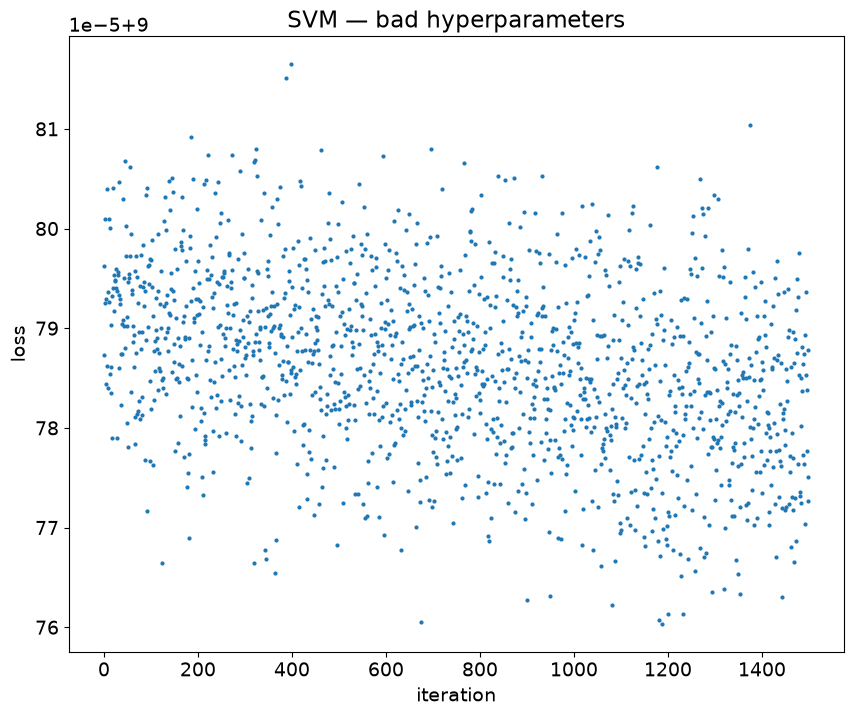

train accuracy: 8.91%   (expect < 20%)
val accuracy: 9.08%   (expect < 20%)


In [8]:
# Deliberately terrible hyperparameters — this cell exists so you can see
# what a dead learning rate looks like. Loss should barely move off ~9.
dl.reset_seed(0)

W_bad, loss_hist = train_linear_classifier(
    svm_loss_vectorized, None,
    data['X_train'], data['y_train'],
    learning_rate=3e-11, reg=2.5e4, num_iters=1500, verbose=True,
)

plt.plot(loss_hist, 'o', markersize=2)
plt.xlabel('iteration'); plt.ylabel('loss'); plt.title('SVM — bad hyperparameters')
plt.show()

for split in ['train', 'val']:
    pred = predict_linear_classifier(W_bad, data[f'X_{split}'])
    acc = 100.0 * (pred == data[f'y_{split}']).double().mean().item()
    print(f'{split} accuracy: {acc:.2f}%   (expect < 20%)')

In [9]:
# Grid search. These are STARTING points, not known-good values — read the
# output and re-center the grid. nan/exploding loss -> lower lr;
# flat accuracy -> raise it. Use num_iters=200 while debugging the loop.
print('SVM grid search')
best_svm, _ = tune(
    LinearSVM,
    learning_rates=[1e-2, 1e-1, 5e-1, 1e0],
    regs=[1e-5, 1e-4, 1e-3],
    num_iters=1500,
)

SVM grid search
  lr 1.0e-02  reg 1.0e-05   train 40.82%   val 38.46%
  lr 1.0e-02  reg 1.0e-04   train 40.84%   val 38.45%
  lr 1.0e-02  reg 1.0e-03   train 40.81%   val 38.49%
  lr 1.0e-01  reg 1.0e-05   train 36.19%   val 32.01%
  lr 1.0e-01  reg 1.0e-04   train 36.45%   val 32.69%
  lr 1.0e-01  reg 1.0e-03   train 36.69%   val 32.87%
  lr 5.0e-01  reg 1.0e-05   train 27.61%   val 25.82%
  lr 5.0e-01  reg 1.0e-04   train 29.89%   val 27.45%
  lr 5.0e-01  reg 1.0e-03   train 30.09%   val 28.29%
  lr 1.0e+00  reg 1.0e-05   train 30.04%   val 27.58%
  lr 1.0e+00  reg 1.0e-04   train 31.54%   val 29.64%
  lr 1.0e+00  reg 1.0e-03   train 28.21%   val 26.75%

best validation accuracy: 38.49%


SVM test accuracy: 38.18%
Saved in /home/saisampathkedari/Deep-Learning/checkpoints/svm_best.pt


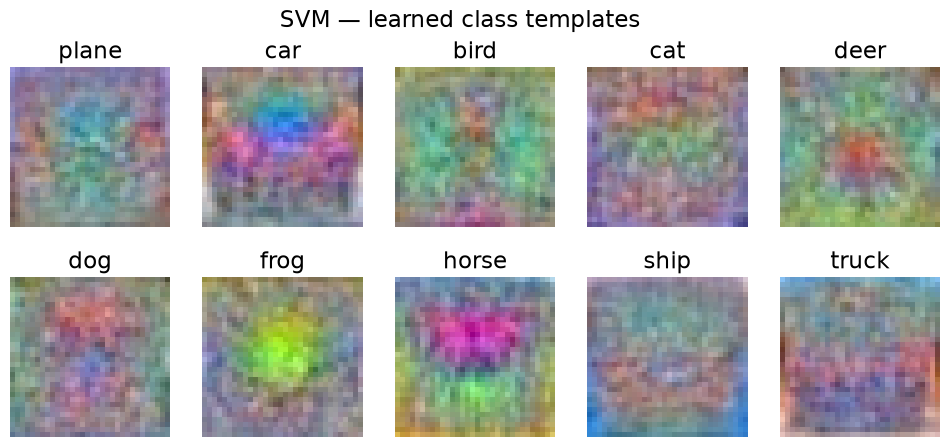

In [10]:
print(f'SVM test accuracy: {accuracy(best_svm, "test"):.2f}%')
best_svm.save(str(CKPT_DIR / 'svm_best.pt'))
show_weights(best_svm.W, 'SVM — learned class templates')

---
# Softmax

In [11]:
# Sanity: near-zero weights -> uniform probabilities over 10 classes,
# so the loss is the entropy of that uniform distribution, log(10).
import math
loss, _ = softmax_loss_naive(random_W(), X_batch, y_batch, reg=0.0)
print(f'Softmax naive loss: {loss.item():.6f}   (expect ~{math.log(10.0):.6f})')

Softmax naive loss: 2.302658   (expect ~2.302585)


In [12]:
for reg in [0.0, 10.0]:
    print(f'--- Softmax grad check, reg={reg:g} ---')
    W = random_W()
    _, grad = softmax_loss_naive(W, X_batch, y_batch, reg)
    f = lambda w, r=reg: softmax_loss_naive(w, X_batch, y_batch, r)[0]
    dl.grad_check.grad_check_sparse(f, W, grad, num_checks=5)
    print()

--- Softmax grad check, reg=0 ---
numerical: 0.003037 analytic: 0.003037, relative error: 1.908649e-06
numerical: 0.006320 analytic: 0.006320, relative error: 3.245704e-07
numerical: 0.005323 analytic: 0.005324, relative error: 5.087487e-07
numerical: 0.002583 analytic: 0.002583, relative error: 6.976762e-07
numerical: 0.007509 analytic: 0.007509, relative error: 4.858134e-07

--- Softmax grad check, reg=10 ---
numerical: 0.003494 analytic: 0.003494, relative error: 1.622608e-06
numerical: 0.009094 analytic: 0.009094, relative error: 2.601654e-07
numerical: 0.003705 analytic: 0.003705, relative error: 6.027159e-07
numerical: 0.001558 analytic: 0.001558, relative error: 1.111698e-06
numerical: 0.006031 analytic: 0.006031, relative error: 5.467339e-07



In [13]:
compare_naive_vectorized(softmax_loss_naive, softmax_loss_vectorized, 5e-2, 'Softmax')

Softmax
  loss difference      8.882e-16   (want < 1e-6)
  gradient difference  0.000e+00   (want < 1e-6)
  speedup              7.0x


In [14]:
# Numeric stability — the ONLY cell that proves the max-subtraction works.
# Weights must be large enough that raw scores exceed ~709, where exp()
# overflows in float64. The second print confirms the test actually stresses
# that; without shifting by the row max, both losses would come out nan.
dl.reset_seed(0)
W_big = 100.0 * torch.randn(D, C, dtype=DTYPE, device=DEVICE)

raw = X_batch @ W_big
print(f'max |raw score|             {raw.abs().max().item():,.0f}   (exp overflows above ~709)')
print(f'unshifted exp() has inf     {torch.isinf(torch.exp(raw)).any().item()}   (must be True or this proves nothing)')
print()

for name, fn in [('naive', softmax_loss_naive), ('vectorized', softmax_loss_vectorized)]:
    loss, grad = fn(W_big, X_batch, y_batch, reg=0.0)
    ok = torch.isfinite(loss).item() and torch.isfinite(grad).all().item()
    print(f'{name:11s} loss={loss.item():12.4f}   finite={ok}')

max |raw score|             5,111   (exp overflows above ~709)
unshifted exp() has inf     True   (must be True or this proves nothing)

naive       loss=   1989.8872   finite=True
vectorized  loss=   1989.8872   finite=True


In [15]:
print('Softmax grid search')
best_softmax, _ = tune(
    Softmax,
    learning_rates=[1e-2, 1e-1, 5e-1, 1e0],
    regs=[1e-5, 1e-4, 1e-3],
    num_iters=1500,
)

Softmax grid search
  lr 1.0e-02  reg 1.0e-05   train 39.99%   val 38.18%
  lr 1.0e-02  reg 1.0e-04   train 39.98%   val 38.18%
  lr 1.0e-02  reg 1.0e-03   train 39.97%   val 38.20%
  lr 1.0e-01  reg 1.0e-05   train 43.15%   val 40.00%
  lr 1.0e-01  reg 1.0e-04   train 43.13%   val 40.00%
  lr 1.0e-01  reg 1.0e-03   train 42.94%   val 39.79%
  lr 5.0e-01  reg 1.0e-05   train 35.56%   val 31.15%
  lr 5.0e-01  reg 1.0e-04   train 35.35%   val 30.99%
  lr 5.0e-01  reg 1.0e-03   train 33.35%   val 30.11%
  lr 1.0e+00  reg 1.0e-05   train 30.01%   val 26.29%
  lr 1.0e+00  reg 1.0e-04   train 27.35%   val 24.78%
  lr 1.0e+00  reg 1.0e-03   train 24.31%   val 22.60%

best validation accuracy: 40.00%


Softmax test accuracy: 40.34%
Saved in /home/saisampathkedari/Deep-Learning/checkpoints/softmax_best.pt


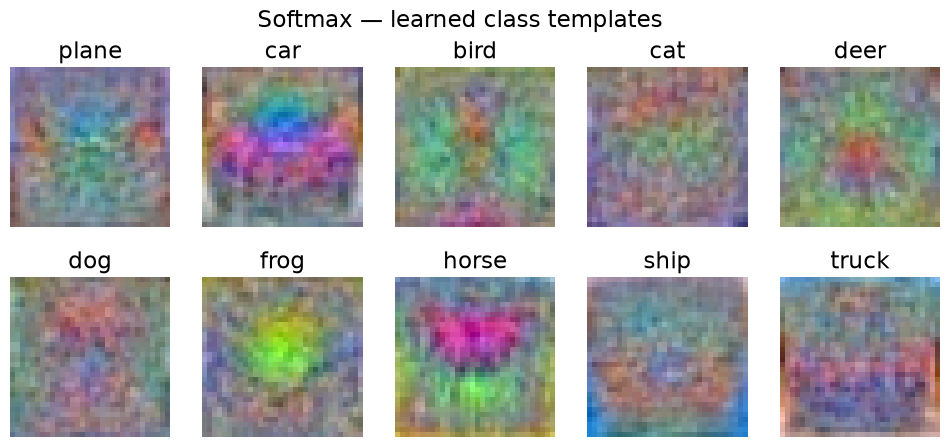

In [16]:
print(f'Softmax test accuracy: {accuracy(best_softmax, "test"):.2f}%')
best_softmax.save(str(CKPT_DIR / 'softmax_best.pt'))
show_weights(best_softmax.W, 'Softmax — learned class templates')